## Access Vessel Bio Optical Backscattering Delayed QC Data (Parquet)

This notebook accesses **in-situ spectral backscattering coefficients** from the
[IMOS Bio-Optical Database of Australian Waters (BODBAW)](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/97b9fe73-ee44-437f-b2ae-5b8613f81042)
measured with a **HydroScat-6 (HS-6)** instrument and produces the visualisations used in
the ocean-colour literature.

### About the dataset

The HS-6 measures the total volume scattering function at 140° to derive the **total
backscattering coefficient** `bb` (m⁻¹) at **6 discrete wavelengths**:
442, 448, 555, 589, 676, and 852 nm.

| Column | Units | Description |
|---|---|---|
| `bb_corr` | m⁻¹ | Corrected total backscattering (bb = bbw + bbp) — calibrated, sigma-corrected |
| `bb_uncorr` | m⁻¹ | Raw (uncorrected) backscattering — before sigma (pathlength) correction |
| `wavelength` | nm | One of 442, 448, 555, 589, 676, 852 nm |

### Oceanographic significance

Backscattering is a fundamental optical property driving satellite ocean-colour signals:

- **bb(555)** (green band) is the primary proxy for **Total Suspended Matter (SPM)** and
  is used directly in MODIS, SeaWiFS, and OLCI ocean-colour algorithms
- **bb(442)/bb(555) spectral ratio** distinguishes sediment-dominated from
  phytoplankton-dominated waters
- **Spectral slope γ**: `bbp(λ) ∝ λ^(−γ)` — γ ≈ 0 (large particles, sediment) to γ ≈ 2
  (small particles, picophytoplankton/colloids) — a key particle-size index
- Negative or near-zero values at 442 nm can indicate over-correction in very clear water

📌 Source maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/blob/main/notebooks/vessel_bio_optical_backscattering_delayed_qc.ipynb)


In [1]:
dataset_name = "vessel_bio_optical_backscattering_delayed_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 484ms
Checked 155 packages in 2ms


✅ Local version 0.3.13 is up to date (remote: 0.3.13)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4063: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 4.73 ms, sys: 1.91 ms, total: 6.64 ms
Wall time: 6.01 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

## List unique partition values

In [6]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 888 µs, sys: 2.3 ms, total: 3.19 ms
Wall time: 2.08 ms


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


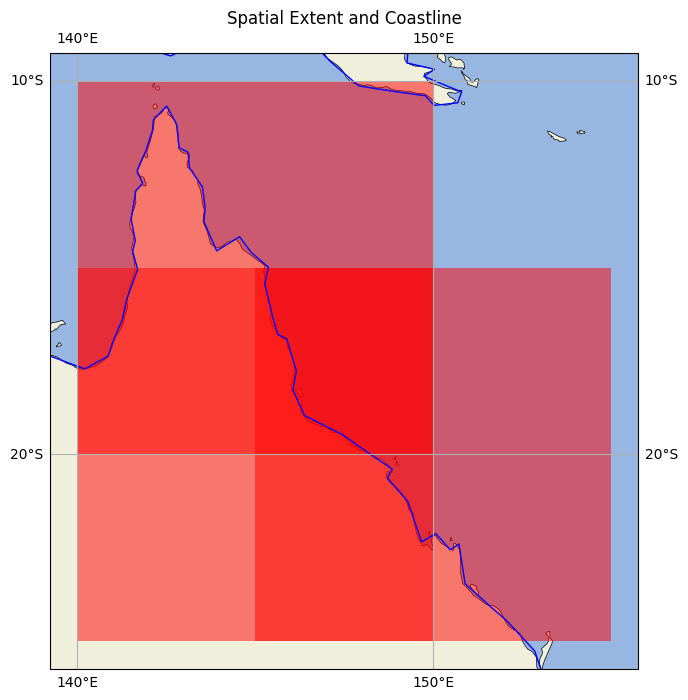

In [7]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similary to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarely accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 110 ms, sys: 149 ms, total: 259 ms
Wall time: 446 ms


(Timestamp('2002-10-21 01:35:46'), Timestamp('2008-04-18 06:55:34'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

2026-04-29 10:32:22,506 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/vessel_bio_optical_backscattering_delayed_qc.parquet


{'timestamp': {'type': 'int64',
  'units': '1',
  'long_name': 'Partition timestamp'},
 'polygon': {'type': 'string',
  'units': '1',
  'long_name': 'Spatial partition polygon'},
 'filename': {'type': 'string',
  'units': '1',
  'long_name': 'Filename of the source file'},
 'TIME': {'type': 'timestamp[ns]',
  'axis': 'T',
  'long_name': 'time',
  'standard_name': 'time'},
 'LATITUDE': {'type': 'float',
  'axis': 'Y',
  'long_name': 'latitude',
  'reference_datum': 'geographical coordinates, WGS84 projection',
  'standard_name': 'latitude',
  'units': 'degrees_north',
  'valid_max': 90.0,
  'valid_min': -90.0},
 'LONGITUDE': {'type': 'float',
  'axis': 'X',
  'long_name': 'longitude',
  'reference_datum': 'geographical coordinates, WGS84 projection',
  'standard_name': 'longitude',
  'units': 'degrees_east',
  'valid_max': 180.0,
  'valid_min': -180.0},
 'DEPTH': {'type': 'float',
  'axis': 'Z',
  'long_name': 'depth',
  'positive': 'down',
  'reference_datum': 'sea surface',
  'standar

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [10]:
%%time
df = aodn_dataset.get_data(#date_start='1994-01-01',
                           #date_end='2023-12-31',
                           lat_min=-45,
                           lat_max=-10,
                           lon_min=110,
                           lon_max=160,
                           )

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Wavelengths (nm): {sorted(df['wavelength'].dropna().unique())}")
print(f"Unique profiles: {df.groupby(['TIME','station_name']).ngroups}")
print(f"bb_corr   non-null: {df['bb_corr'].notna().sum():,}  range: {df['bb_corr'].min():.4f}–{df['bb_corr'].max():.4f} m⁻¹")
print(f"bb_uncorr non-null: {df['bb_uncorr'].notna().sum():,}")
df.head(3)


2026-04-29 10:32:25,250 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/vessel_bio_optical_backscattering_delayed_qc.parquet


Rows: 267,558  |  Columns: 11
Wavelengths (nm): [442.0, 448.0, 555.0, 589.0, 676.0, 852.0]
Unique profiles: 14514
bb_corr   non-null: 29,700  range: -99.0000–3.5132 m⁻¹
bb_uncorr non-null: 29,700
CPU times: user 438 ms, sys: 137 ms, total: 575 ms
Wall time: 2.7 s


,filename,TIME,LATITUDE,LONGITUDE,DEPTH,station_name,wavelength,bb_corr,bb_uncorr,timestamp,polygon
0,IMOS_SRS-OC-BODBAW_X_20021021T013546Z_LB3172-S...,2002-10-21 01:55:26,-18.27,147.300003,0.0,SAT001,442.0,0.484142,0.003367,1009843200,0103000000010000000500000000000000008061400000...
1,IMOS_SRS-OC-BODBAW_X_20021021T013546Z_LB3172-S...,2002-10-21 01:55:26,-18.27,147.300003,0.0,SAT001,448.0,0.277116,0.002048,1009843200,0103000000010000000500000000000000008061400000...
2,IMOS_SRS-OC-BODBAW_X_20021021T013546Z_LB3172-S...,2002-10-21 01:55:26,-18.27,147.300003,0.0,SAT001,555.0,0.169247,0.001303,1009843200,0103000000010000000500000000000000008061400000...


In [11]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


df.aodn.download_as_csv()

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/aodn_metadata-uuid_97b9fe73-ee44-437f-b2ae-5b8613f81042_vessel_bio_optical_backscattering_delayed_qc_data-hash_3319a481.csv.zip

## Create a TIME and scalar/number filter

This cell filters the dataset by time range and a scalar value (from a Parquet partition) using the `scalar_filter` argument.  
This leverages Parquet partitioning to apply efficient, server-side filtering, which significantly speeds up data loading.

## Surface Backscattering Spectra

Backscattering coefficient `bb_corr(λ)` at the sea surface (depth ≤ 2 m) plotted against
wavelength. The HS-6 has only 6 discrete bands, so each profile appears as a 6-point curve.

Characteristic spectral shapes:
- **Decreasing with wavelength** (negative spectral slope) → typical; more scattering at
  shorter wavelengths due to smaller Rayleigh-like particles
- **Flat or increasing toward red** → large mineral/sediment particles dominating (e.g. turbid
  coastal plumes, river-influenced stations)
- Values near zero or negative at 442 nm → near clear-water conditions where correction
  uncertainty is comparable to the signal

Individual profiles are thin translucent lines; the **median spectrum** is the thick line.


Surface profiles at 6 wavelengths: ['442', '448', '555', '589', '676', '852'] nm


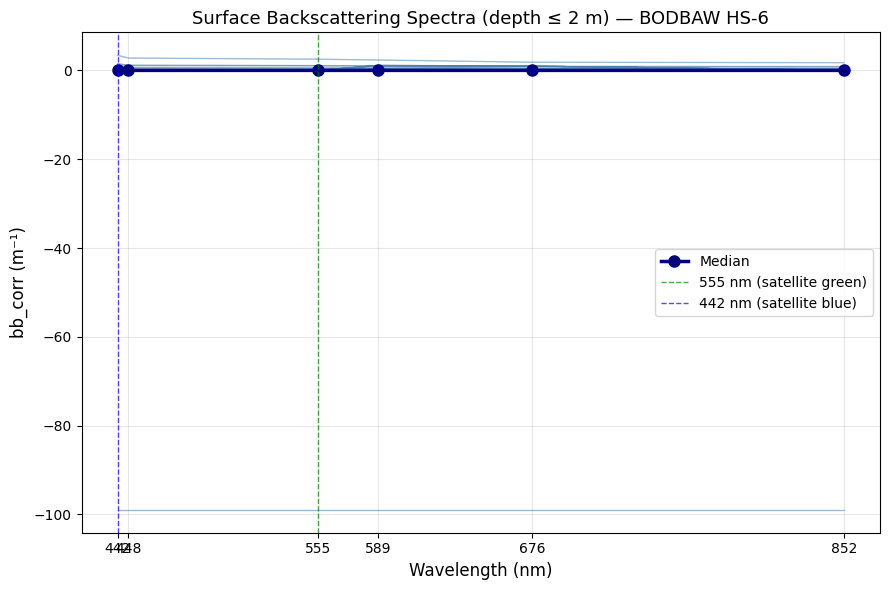

In [12]:
import matplotlib.pyplot as plt
import numpy as np

df_surf = df[(df['DEPTH'] <= 2) & df['bb_corr'].notna()].copy()
df_surf = df_surf.sort_values('wavelength')
wavelengths = sorted(df_surf['wavelength'].unique())
print(f"Surface profiles at {len(wavelengths)} wavelengths: {[f'{w:.0f}' for w in wavelengths]} nm")

fig, ax = plt.subplots(figsize=(9, 6))

for _, grp in df_surf.groupby(['TIME', 'station_name', 'DEPTH']):
    grp = grp.sort_values('wavelength')
    if len(grp) < 4:
        continue
    ax.plot(grp['wavelength'], grp['bb_corr'], color='steelblue', alpha=0.07, linewidth=0.8)

# Median spectrum across all surface profiles
med = df_surf.groupby('wavelength')['bb_corr'].median()
ax.plot(med.index, med.values, 'o-', color='navy', linewidth=2.5, markersize=8, label='Median')

ax.axvline(555, color='green', linestyle='--', linewidth=1, alpha=0.7, label='555 nm (satellite green)')
ax.axvline(442, color='blue',  linestyle='--', linewidth=1, alpha=0.7, label='442 nm (satellite blue)')
ax.set_xticks(wavelengths)
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('bb_corr (m⁻¹)', fontsize=12)
ax.set_title('Surface Backscattering Spectra (depth ≤ 2 m) — BODBAW HS-6', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Spatial Distribution at 555 nm

**555 nm** (MODIS green band) is the standard reference wavelength for SPM retrieval and
turbidity assessment from satellites. Higher `bb_corr(555)` indicates more turbid, particle-rich water.

Typical ranges:
- < 0.002 m⁻¹ → clear open-ocean water
- 0.002–0.01 m⁻¹ → moderately productive/coastal water  
- > 0.01 m⁻¹ → turbid coastal water, river plumes, resuspension


Using wavelength: 555 nm


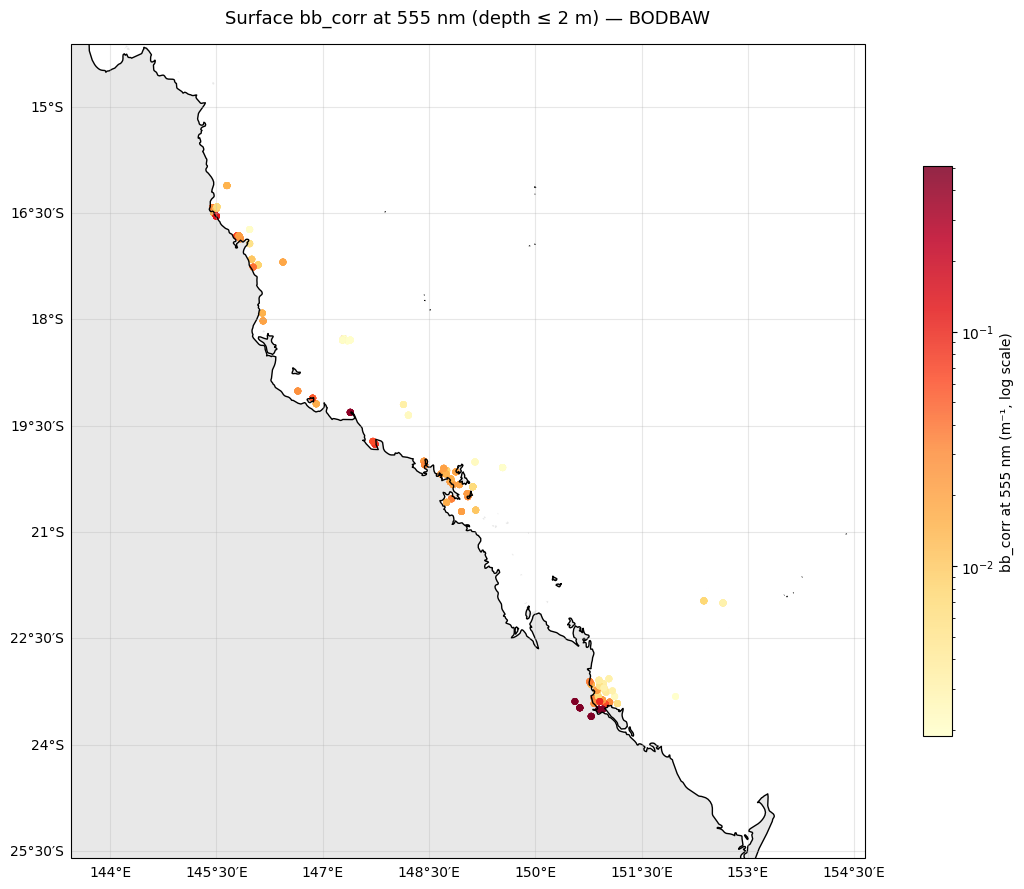

n = 863  |  median bb(555) = 0.0162 m⁻¹


In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Nearest wavelength to 555 nm
all_wl = df['wavelength'].dropna().unique()
nearest_555 = all_wl[np.argmin(np.abs(all_wl - 555))]
print(f"Using wavelength: {nearest_555:.0f} nm")

df_555 = df[(df['wavelength'] == nearest_555) & (df['DEPTH'] <= 2)].copy()
df_555 = df_555.dropna(subset=['bb_corr', 'LATITUDE', 'LONGITUDE'])
df_555 = df_555[df_555['bb_corr'] > 0]

if df_555.empty:
    print("No surface bb_corr data at 555 nm in this region.")
else:
    fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': ccrs.PlateCarree()})

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    sc = ax.scatter(df_555['LONGITUDE'], df_555['LATITUDE'],
                    c=df_555['bb_corr'],
                    norm=mcolors.LogNorm(vmin=df_555['bb_corr'].quantile(0.05).clip(1e-4),
                                         vmax=df_555['bb_corr'].quantile(0.95)),
                    cmap='YlOrRd', s=25, alpha=0.85, edgecolors='none',
                    transform=ccrs.PlateCarree())

    plt.colorbar(sc, ax=ax, label='bb_corr at 555 nm (m⁻¹, log scale)', shrink=0.7, pad=0.05)

    lon_pad = max((df_555['LONGITUDE'].max() - df_555['LONGITUDE'].min()) * 0.05, 2)
    lat_pad = max((df_555['LATITUDE'].max()  - df_555['LATITUDE'].min())  * 0.05, 2)
    ax.set_extent([df_555['LONGITUDE'].min() - lon_pad, df_555['LONGITUDE'].max() + lon_pad,
                   df_555['LATITUDE'].min()  - lat_pad, df_555['LATITUDE'].max()  + lat_pad])

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title('Surface bb_corr at 555 nm (depth ≤ 2 m) — BODBAW', fontsize=13, pad=15)
    plt.tight_layout()
    plt.show()
    print(f"n = {len(df_555):,}  |  median bb(555) = {df_555['bb_corr'].median():.4f} m⁻¹")


## Depth Profiles at 555 nm

Vertical structure of backscattering at 555 nm reveals:
- **Uniform profile** → well-mixed water column (wind-driven turbulence)
- **Surface maximum** → phytoplankton bloom or river plume confined to upper layer
- **Subsurface maximum** → Deep Particle Maximum (DPM) — particles accumulating at a density interface
- **Bottom increase** → sediment resuspension by tidal or bottom-boundary-layer currents


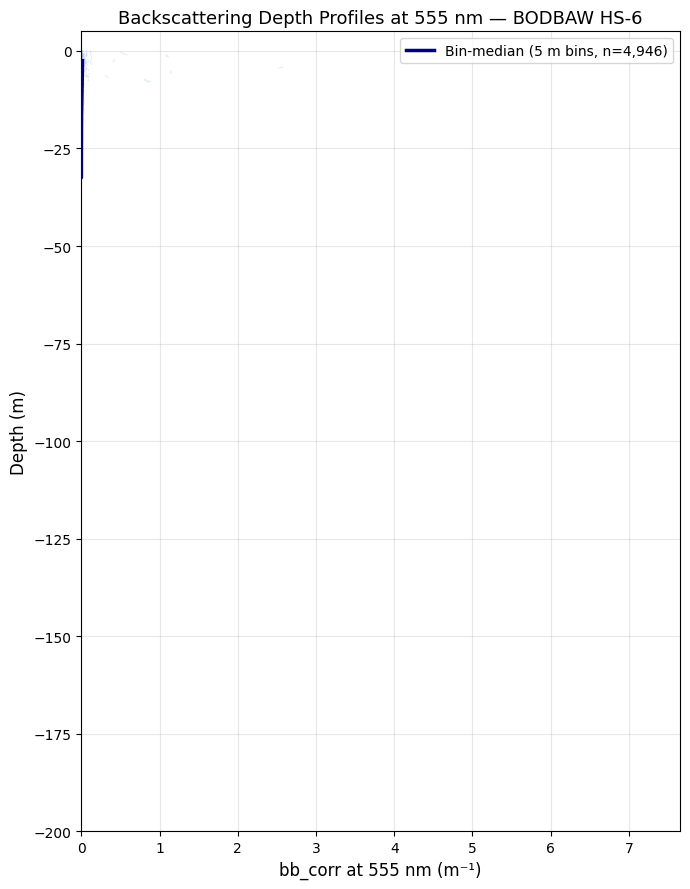

In [14]:
import matplotlib.pyplot as plt
import numpy as np

all_wl = df['wavelength'].dropna().unique()
nearest_555 = all_wl[np.argmin(np.abs(all_wl - 555))]

df_dp = df[(df['wavelength'] == nearest_555) & df['bb_corr'].notna()].copy()
df_dp = df_dp[(df_dp['DEPTH'] >= 0) & (df_dp['DEPTH'] <= 200)]

fig, ax = plt.subplots(figsize=(7, 9))

for _, grp in df_dp.groupby(['TIME', 'station_name']):
    grp = grp.sort_values('DEPTH')
    if len(grp) < 2:
        continue
    ax.plot(grp['bb_corr'], -grp['DEPTH'], color='steelblue', alpha=0.15, linewidth=0.7)

# Bin-median profile (5 m bins)
df_dp['depth_bin'] = (df_dp['DEPTH'] // 5) * 5 + 2.5
med_prof = df_dp.groupby('depth_bin')['bb_corr'].median()
ax.plot(med_prof.values, -med_prof.index, color='navy', linewidth=2.5,
        label=f'Bin-median (5 m bins, n={len(df_dp):,})', zorder=5)

ax.set_xlabel('bb_corr at 555 nm (m⁻¹)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title('Backscattering Depth Profiles at 555 nm — BODBAW HS-6', fontsize=13)
ax.set_ylim(-200, 5)
ax.set_xlim(left=0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Backscattering Spectral Slope γ (Particle Size Index)

Particulate backscattering follows a power law:

$$b_{bp}(\lambda) = b_{bp}(\lambda_0) \cdot \left(\frac{\lambda}{\lambda_0}\right)^{-\gamma}$$

The spectral slope **γ** (gamma) is a proxy for the **particle size distribution (PSD)**:

| γ value | Interpretation |
|---|---|
| γ ≈ 0 | Large particles dominate (mineral sediment, large phytoplankton) |
| γ ≈ 1 | Mixed particle population (typical coastal water) |
| γ ≈ 2 | Small particles dominate (picoplankton, colloids, clear offshore water) |

We estimate γ by fitting a log-linear regression to `log(bb_corr)` vs `log(λ)` across all 6 bands,
excluding wavelengths where `bb_corr ≤ 0` (over-corrected values).


Profiles fitted: 748
γ median: 0.82
γ IQR:    0.69 – 1.06


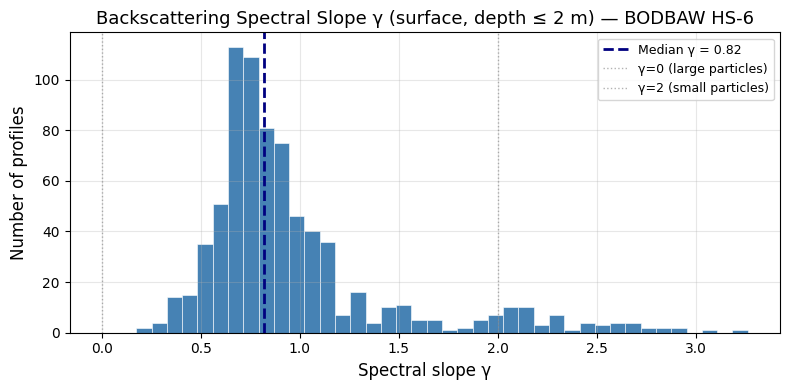

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

gamma_values = []
for (time, sta, depth), grp in df[df['DEPTH'] <= 2].groupby(['TIME', 'station_name', 'DEPTH']):
    grp = grp.sort_values('wavelength')
    valid = grp[grp['bb_corr'] > 0].dropna(subset=['bb_corr'])
    if len(valid) < 4:   # need at least 4 wavelengths for a reliable fit
        continue
    try:
        slope, *_ = linregress(np.log(valid['wavelength']), np.log(valid['bb_corr']))
        g = -slope
        if -1 < g < 4:   # physically plausible range
            gamma_values.append(g)
    except Exception:
        pass

gamma_values = np.array(gamma_values)

if len(gamma_values) == 0:
    print("No profiles could be fitted — check that bb_corr data is present in the filtered region.")
else:
    print(f"Profiles fitted: {len(gamma_values)}")
    print(f"γ median: {np.median(gamma_values):.2f}")
    print(f"γ IQR:    {np.percentile(gamma_values,25):.2f} – {np.percentile(gamma_values,75):.2f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(gamma_values, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(np.median(gamma_values), color='navy', linestyle='--', linewidth=2,
               label=f'Median γ = {np.median(gamma_values):.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.6, label='γ=0 (large particles)')
    ax.axvline(2, color='gray', linestyle=':', linewidth=1, alpha=0.6, label='γ=2 (small particles)')
    ax.set_xlabel('Spectral slope γ', fontsize=12)
    ax.set_ylabel('Number of profiles', fontsize=12)
    ax.set_title('Backscattering Spectral Slope γ (surface, depth ≤ 2 m) — BODBAW HS-6', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Correction Quality: Corrected vs Uncorrected Backscattering

The HS-6 raw signal (`bb_uncorr`) requires a **sigma (path-length) correction** to account
for absorption affecting the measured scattering volume. The corrected value (`bb_corr`)
is the scientifically valid quantity used in all analyses above.

This scatter plot at 555 nm shows how large the correction is and identifies any outliers:
- Points close to the **1:1 line** → small correction, low absorption waters
- Points significantly **below** the 1:1 line → large correction applied (high absorption, turbid water)
- Points with `bb_corr < 0` → over-correction (typically at blue wavelengths in clear water — exclude)


Median correction: -2.5% of raw signal
Max correction:    3.5% (95th percentile)


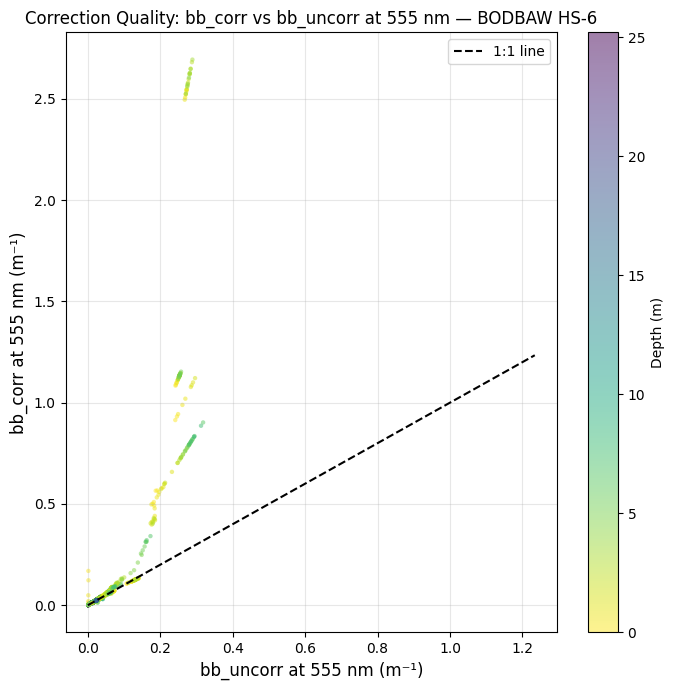

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

all_wl = df['wavelength'].dropna().unique()
nearest_555 = all_wl[np.argmin(np.abs(all_wl - 555))]

df_cmp = df[(df['wavelength'] == nearest_555)].dropna(subset=['bb_corr', 'bb_uncorr']).copy()
df_cmp = df_cmp[(df_cmp['bb_corr'] > 0) & (df_cmp['bb_uncorr'] > 0)]

if df_cmp.empty:
    print("No overlapping bb_corr / bb_uncorr data at 555 nm.")
else:
    fig, ax = plt.subplots(figsize=(7, 7))

    sc = ax.scatter(df_cmp['bb_uncorr'], df_cmp['bb_corr'],
                    c=df_cmp['DEPTH'], cmap='viridis_r',
                    norm=mcolors.Normalize(vmin=0, vmax=min(df_cmp['DEPTH'].quantile(0.95), 200)),
                    s=10, alpha=0.5, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Depth (m)')

    lim = max(df_cmp['bb_uncorr'].quantile(0.99), df_cmp['bb_corr'].quantile(0.99)) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='1:1 line')
    ax.set_xlabel('bb_uncorr at 555 nm (m⁻¹)', fontsize=12)
    ax.set_ylabel('bb_corr at 555 nm (m⁻¹)', fontsize=12)
    ax.set_title('Correction Quality: bb_corr vs bb_uncorr at 555 nm — BODBAW HS-6', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Compute correction ratio
    ratio = (df_cmp['bb_uncorr'] - df_cmp['bb_corr']) / df_cmp['bb_uncorr']
    print(f"Median correction: {ratio.median()*100:.1f}% of raw signal")
    print(f"Max correction:    {ratio.quantile(0.95)*100:.1f}% (95th percentile)")

    plt.tight_layout()
    plt.show()
